## Dog Breed Classification CNN 

Importing The Required Libraries

In [173]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import tf_keras as keras


In [174]:
dog_labels = pd.read_csv("Datasets/labels.csv")
dog_labels.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


Text(0, 0.5, 'Count')

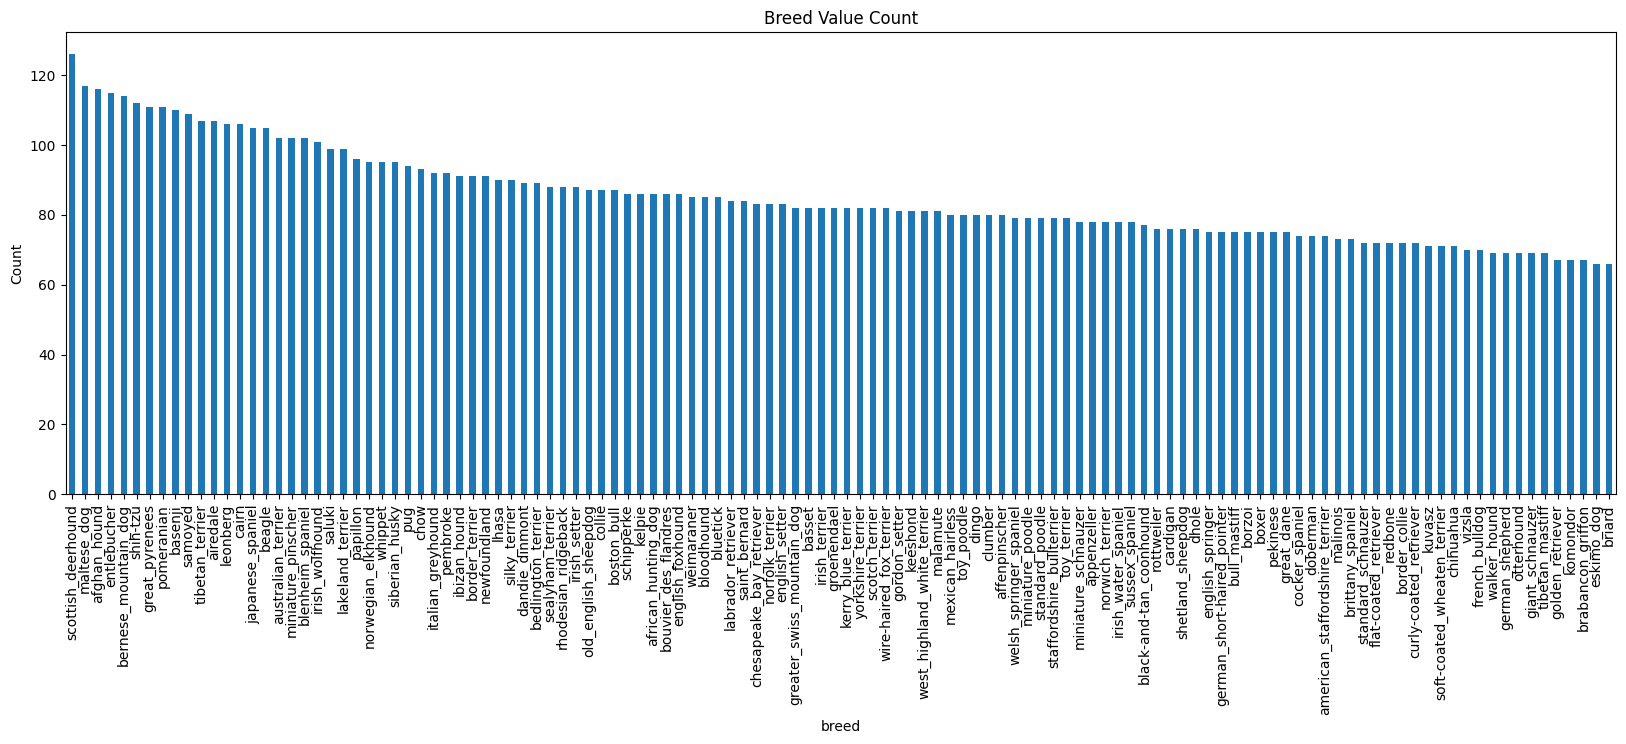

In [175]:
dog_labels.breed.value_counts().plot(kind="bar",figsize=(20,6))
plt.title("Breed Value Count")
plt.ylabel("Count")

Map The Images To The ID

In [176]:
dog_labels["file_path"] = dog_labels["id"].apply(lambda x: f"Datasets/train/{x}.jpg")

Displaying An Image

Text(0.5, 1.0, 'bedlington_terrier')

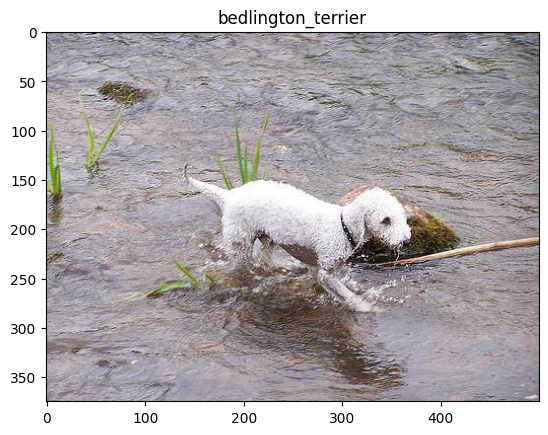

In [177]:
filepath = dog_labels["file_path"].iloc[5]
image = plt.imread(filepath)
plt.imshow(image)
plt.title(dog_labels.breed.iloc[5])


Preprocessing The Data

In [178]:
train_images = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    validation_split=0.2,
)

process_train_images = train_images.flow_from_dataframe(
    dog_labels,
    x_col="file_path",
    y_col="breed",
    target_size=(128,128),
    class_mode='categorical',
    batch_size=32,
    subset="training",
    shuffle=True
)

process_val_images = train_images.flow_from_dataframe(
    dog_labels,
    x_col="file_path",
    y_col="breed",
    target_size=(128,128),
    class_mode='categorical',
    batch_size=32,
    subset="validation",
    shuffle=True
)


Found 8178 validated image filenames belonging to 120 classes.
Found 2044 validated image filenames belonging to 120 classes.


Building The Convolutional Neural Network

In [179]:
# dog_cnn = tf.keras.models.Sequential([
#     # Input Layer
#     tf.keras.layers.Input(shape=(128, 128, 3)),

#     # Convolutional Block 1
#     tf.keras.layers.Conv2D(8, (3, 3), activation="relu"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D((2, 2)),
#     # Convolutional Block 2
#     tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D((2, 2)),

#     # Convolutional Block 3
#     tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D((2, 2)),

#     # Convolutional Block 4
#     tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D((2, 2)),

#     # Convolutional Block 5
#     tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D((2, 2)),

#     # Global Average Pooling
#     tf.keras.layers.Flatten(),

#     # Dense Layers
#     tf.keras.layers.Dense(512, activation="relu"),
#     tf.keras.layers.Dropout(0.5),  # Dropout Regularization
#     tf.keras.layers.Dense(120, activation="softmax")
# ])


In [180]:
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable=False
# Add custom classification head
x = tf.keras.layers.Flatten()(base_model.output)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(120, activation='softmax')(x)

dog_cnn = tf.keras.models.Model(inputs=base_model.input, outputs=output)


In [181]:
dog_cnn.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 12,805,816 (48.85 MB)

 Trainable params: 10,547,832 (40.24 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Early Stop Callback

In [182]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=10, restore_best_weights=True)

In [183]:
dog_cnn.compile(optimizer=tf.keras.optimizers.Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

Training The Model

In [184]:
# dog_cnn.fit(process_train_images, validation_data=process_val_images, epochs=100, callbacks=[early_stopping])

Saving The Model

In [185]:
# dog_cnn.save("SavedModel/dog_cnn.h5")

Loading The Model

In [186]:
dog_cnn = tf.keras.models.load_model("SavedModel/dog_cnn.h5")
# dog_cnn.summary()

Making A Prediction

In [187]:
def preprocessing_image(filepath):
    image = tf.keras.preprocessing.image.load_img(filepath,target_size=(128,128))
    image_arr = tf.keras.preprocessing.image.img_to_array(image)
    image_scaled = image_arr/255
    image_scaled = np.expand_dims(image_scaled,axis=0)
    return image_scaled



In [188]:
image = "Datasets/test/0a0b97441050bba8e733506de4655ea1.jpg"
proprocessed_image = preprocessing_image(image)
prediction = dog_cnn.predict(proprocessed_image)
prediction_class = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step


In [189]:
print(f"Predicted Breed : {np.unique(dog_labels.breed)[prediction_class]}")
print(f"Prediction Probability : {prediction[0][prediction_class]}")

Predicted Breed : black-and-tan_coonhound
Prediction Probability : 0.704063355922699


Evaluating The Neural Network

In [190]:
prediction_val = dog_cnn.predict(process_val_images)

c:\Python\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step


In [191]:
prediction_val_class = np.argmax(prediction_val,axis=1)
true_classes = process_val_images.classes
class_labels = list(process_val_images.class_indices.keys())

In [192]:
report = classification_report(true_classes,prediction_val_class,target_names=class_labels)
print(report)

                                precision    recall  f1-score   support

                 affenpinscher       0.00      0.00      0.00        19
                  afghan_hound       0.00      0.00      0.00        21
           african_hunting_dog       0.00      0.00      0.00        13
                      airedale       0.00      0.00      0.00        23
american_staffordshire_terrier       0.00      0.00      0.00        13
                   appenzeller       0.00      0.00      0.00        18
            australian_terrier       0.00      0.00      0.00        21
                       basenji       0.00      0.00      0.00        26
                        basset       0.00      0.00      0.00        18
                        beagle       0.00      0.00      0.00        17
            bedlington_terrier       0.06      0.04      0.05        27
          bernese_mountain_dog       0.00      0.00      0.00        26
       black-and-tan_coonhound       0.00      0.00      0.00  

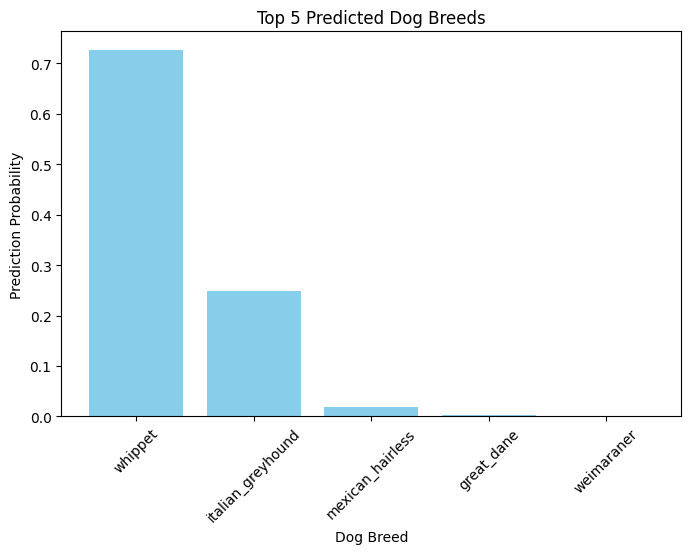

In [193]:
top_5_indices = np.argsort(prediction_val[0])[-5:][::-1]

top_5_probabilities = [prediction_val[0][i] for i in top_5_indices]
top_5_breeds = [np.unique(dog_labels.breed)[i] for i in top_5_indices]

plt.figure(figsize=(8, 5))
plt.bar(top_5_breeds, top_5_probabilities, color='skyblue')
plt.xlabel('Dog Breed')
plt.ylabel('Prediction Probability')
plt.title('Top 5 Predicted Dog Breeds')
plt.xticks(rotation=45)
plt.show()
